In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2 
import os

In [2]:
import xml.etree.ElementTree as ET 
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

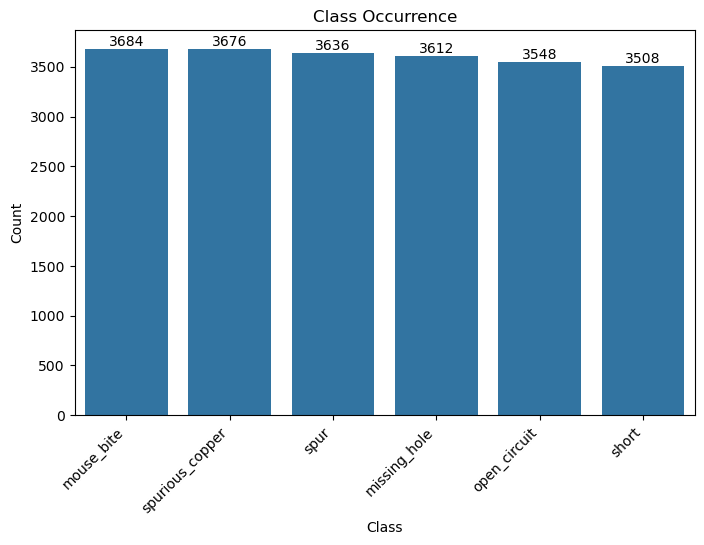

In [30]:
# task: display the distribution of anomaly class occurance in dataset

import seaborn as sns
file_path = "C:\\Users\\faiza\\Downloads\\VOC_PCB\\VOC_PCB\\PCB_annotations_dataset.csv"
df = pd.read_csv(file_path, sep=';')

#print(df.head())

# Task: Bar chart for the occurrence of each class
class_counts = df['class'].value_counts()
#print(class_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom')

plt.title('Class Occurrence')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [3]:
image_path = os.path.join(os.getcwd(), 'PCB_dataset\images')
print(image_path)

generated_images_path = os.path.join(os.getcwd(), 'PCB_dataset\generated_images')
print(generated_images_path)

c:\Users\faiza\Documents\GitHub\PCB_Defects_Detection\Visualizations_prep\PCB_dataset\images
c:\Users\faiza\Documents\GitHub\PCB_Defects_Detection\Visualizations_prep\PCB_dataset\generated_images


In [4]:
def populate_image_dataset(image_path):
    # Create directory for generated images if it doesn't exist
    
    if os.path.exists(generated_images_path):
        print('Generated images directory exsists.')
    else:
        os.makedirs(generated_images_path, exist_ok=True)
        print('Generated images directory generated.')
   
    images = os.listdir(image_path)
    
    for img_name in images:
        img_path = os.path.join(image_path, img_name)
        img = cv2.imread(img_path)

        image_name = f"{os.path.splitext(img_name)[0]}.jpg"
        img_org_path= os.path.join(generated_images_path, image_name)
        cv2.imwrite(img_path, img)
        
        # Rotate the image by 90, 180, and 270 degrees
        for angle in [90, 180, 270]:
            rotated_img = np.rot90(img, k=angle // 90)
            rotated_img_name = f"{os.path.splitext(img_name)[0]}_rotated_{angle}.jpg"
            rotated_img_path = os.path.join(generated_images_path, rotated_img_name)
            cv2.imwrite(rotated_img_path, rotated_img)
            
        # Flip the image horizontally
        flipped_img = cv2.flip(img, 1)
        flipped_img_name = f"{os.path.splitext(img_name)[0]}_flipped.jpg"
        flipped_img_path = os.path.join(generated_images_path, flipped_img_name)
        cv2.imwrite(flipped_img_path, flipped_img)



In [8]:
# task: populating images dataset by rotating (90, 180, 270) and flipping the images
populate_image_dataset(image_path)

Generated images directory exsists.


In [9]:
def superimpose_images(image_dir):
    # Load processed images
    images = [cv2.imread(os.path.join(image_dir, file)) for file in os.listdir(image_dir)]
    
    # Create blank canvas (background image)
    background = np.zeros_like(images[0], dtype=np.uint8)
    
    # Superimpose images
    for image in images:
        # Add each processed image to the background with transparency
        overlay = np.zeros_like(background)
        overlay[:image.shape[0], :image.shape[1]] = image
        background = cv2.addWeighted(background, 0.5, overlay, 0.3, 0)  # Adjust transparency as needed
    
    # Display composite image using Matplotlib
    plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

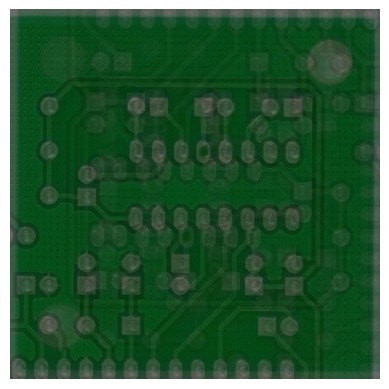

In [10]:
# task: generate superimposed image from images dataset
superimpose_images(generated_images_path)

In [11]:
images = os.listdir(image_path)
print(images)

['l_light_01_missing_hole_01_1_600.jpg', 'l_light_01_missing_hole_01_2_600.jpg', 'l_light_01_missing_hole_02_1_600.jpg', 'l_light_01_missing_hole_02_2_600.jpg', 'l_light_01_missing_hole_02_3_600.jpg', 'l_light_01_missing_hole_03_1_600.jpg', 'l_light_01_missing_hole_03_2_600.jpg', 'l_light_01_missing_hole_04_1_600.jpg', 'l_light_01_missing_hole_04_2_600.jpg', 'l_light_01_missing_hole_05_1_600.jpg', 'l_light_01_missing_hole_05_2_600.jpg', 'l_light_01_missing_hole_06_1_600.jpg', 'l_light_01_missing_hole_06_2_600.jpg', 'l_light_01_missing_hole_06_3_600.jpg', 'l_light_01_missing_hole_07_1_600.jpg', 'l_light_01_missing_hole_07_2_600.jpg', 'l_light_01_missing_hole_08_1_600.jpg', 'l_light_01_missing_hole_08_2_600.jpg', 'l_light_01_missing_hole_08_3_600.jpg', 'l_light_01_missing_hole_09_1_600.jpg', 'l_light_01_missing_hole_09_2_600.jpg', 'l_light_01_missing_hole_09_3_600.jpg', 'l_light_01_missing_hole_10_1_600.jpg', 'l_light_01_missing_hole_10_2_600.jpg', 'l_light_01_missing_hole_10_3_600.jpg',

In [12]:
#augmenting the dataset
def annotation_generation(all_files, dataset):
    for annotations in all_files:
        tree = ET.parse(annotations)
        for element in tree.iter():
            if 'size' in element.tag:
                for attribute in list(element):
                    if 'width' in attribute.tag: 
                        width = int(round(float(attribute.text)))
            
                    if 'height' in attribute.tag:
                        height = int(round(float(attribute.text)))  
                        
                    if 'depth' in attribute.tag:
                        depth = int(round(float(attribute.text)))    

            if 'object' in element.tag:
                # print('[object] in element.tag ==> list(elem)\n'), print(list(element))
                for attribute in list(element):
                    
                    # print('attr = %s\n' % attr)
                    if 'name' in attribute.tag:
                        name = attribute.text                 
                        dataset['class']+=[name]
                        dataset['width']+=[width]
                        dataset['height']+=[height] 
                        dataset['depth']+=[depth] 
                        dataset['file']+=[annotations.split('/')[-1][0:-4]] 
                                
                    if 'bndbox' in attribute.tag:
                        for dimensions in list(attribute):
                            if 'xmin' in dimensions.tag:
                                xmin = int(round(float(dimensions.text)))
                                dataset['xmin']+=[xmin]
                            if 'ymin' in dimensions.tag:
                                ymin = int(round(float(dimensions.text)))
                                dataset['ymin']+=[ymin]                                
                            if 'xmax' in dimensions.tag:
                                xmax = int(round(float(dimensions.text)))
                                dataset['xmax']+=[xmax]                                
                            if 'ymax' in dimensions.tag:
                                ymax = int(round(float(dimensions.text)))
                                dataset['ymax']+=[ymax]  
    return dataset

In [13]:
def generate_csv_file(image_dir):
    dataset = {
            "file":[],
            "width":[],
            "height":[],
            "depth":[],
            "class":[],
            "xmin":[],
            "ymin":[],   
            "xmax":[],
            "ymax":[],
           }

    all_files = []
    images = {os.path.splitext(image)[0] for image in os.listdir(image_dir)}
    # print(images)

    #path where the Annotations xml files are stored within the extracted dataset folder
    annotations_file_location = "C:/Users/faiza/Downloads/VOC_PCB/VOC_PCB/Annotations/"

    for path, subdirs, files in os.walk(annotations_file_location):
        for name in files:
            filename = name.split('.')[0]
            if filename in images:
                all_files.append(os.path.join(path, name))

   
    annotation_generation(all_files,dataset)

    df=pd.DataFrame(dataset)
    #print(df.head(10))

    df.index.name = 'Index'

    df.to_csv("PCB_annotations_dataset_minimized.csv", sep=';')

In [14]:
# task: generating the csv file for subset of the dataset by parsing from complete xml database
generate_csv_file(image_path)

In [15]:
df = pd.read_csv('PCB_annotations_dataset_minimized.csv', sep=';')

In [16]:
# task : Crosstab for the max amount of defects in one image file from the subset of the dataset
max_defects_file = df.groupby('file')['class'].count().idxmax()
max_defects = pd.crosstab(df[df['file'] == max_defects_file]['file'], df[df['file'] == max_defects_file]['class'])
print("Max Defects :")
print(max_defects)

Max Defects :
class                             missing_hole
file                                          
l_light_01_missing_hole_01_2_600             2


In [17]:
# task: display 5 images with the maximum occurrences of defects
count_defects = df.groupby(['file', 'class']).size().reset_index(name='count')
max_defects_files = count_defects.groupby('file')['count'].transform(max) == count_defects['count']
max_defects = count_defects[max_defects_files].nlargest(5, 'count')
print("Top 5 Defects with Max Occurrences in One Image File:")
print(max_defects)

Top 5 Defects with Max Occurrences in One Image File:
                               file         class  count
1  l_light_01_missing_hole_01_2_600  missing_hole      2
2  l_light_01_missing_hole_02_1_600  missing_hole      2
5  l_light_01_missing_hole_03_1_600  missing_hole      2
8  l_light_01_missing_hole_04_2_600  missing_hole      2
9  l_light_01_missing_hole_05_1_600  missing_hole      2


In [21]:
def visualize_bounding_boxes(image_path, image_to_plot, df, num_defects):
    # plt.figure(figsize=(10, 10))
    
    # fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for image_name in image_to_plot:
        # Plotting original image
        original_image_path = f"{os.path.join(image_path, image_name)}.jpg"
        print(original_image_path)
                                           
        # original_image = plt.imread(original_image_path)
        original_image = cv2.imread(original_image_path)
        original_image_with_boxes = original_image.copy()

        # axes[0].imshow(original_image)
        # axes[0].set_title('Original Image')
        # axes[0].set_xticks([])
        # axes[0].set_yticks([])

        # Plotting bounding rectangles for all the defects
        df_image = df[df['file'] == image_name]
        for index, row in df_image.iterrows():
            xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
            # rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='r', facecolor='none')
            # axes[1].add_patch(rect)
            cv2.rectangle(original_image_with_boxes, (xmin, ymin), (xmax, ymax), (0, 0, 255), 2)  
        

        # Turn off axis ticks and labels for the second plot
        # axes[1].set_xticks([])
        # axes[1].set_yticks([])
        # axes[1].set_xticklabels([])
        # axes[1].set_yticklabels([])

        # axes[1].imshow(original_image)
        # axes[1].set_title('Bounding boxes Image')

        # plt.tight_layout()
        # plt.show()
        # Display the image with bounding boxes
        cv2.imshow('Bounding boxes Image', original_image_with_boxes)
        cv2.waitKey(0)  # Wait for a key press to close the window

        output_image_path = f"{os.path.join(image_name)}_bbox.jpg"
        cv2.imwrite(output_image_path, original_image_with_boxes)

In [19]:
#taking as input how many defects user wants to see
num_defects = int(input("Enter the number of defects you want to see: "))

# taking user input for the number of files to show
num_files_to_show = int(input("Enter the number of files you want to see: "))


image_num_defects = count_defects[count_defects['count'] == num_defects]['file'][:num_files_to_show]

print(image_num_defects.values)

['l_light_01_missing_hole_01_2_600' 'l_light_01_missing_hole_02_1_600'
 'l_light_01_missing_hole_03_1_600']


In [22]:
# task: generating the images with bounding boxes
visualize_bounding_boxes(image_path, image_num_defects.values, df, num_defects)

c:\Users\faiza\Documents\GitHub\PCB_Defects_Detection\Visualizations_prep\PCB_dataset\images\l_light_01_missing_hole_01_2_600.jpg
c:\Users\faiza\Documents\GitHub\PCB_Defects_Detection\Visualizations_prep\PCB_dataset\images\l_light_01_missing_hole_02_1_600.jpg
c:\Users\faiza\Documents\GitHub\PCB_Defects_Detection\Visualizations_prep\PCB_dataset\images\l_light_01_missing_hole_03_1_600.jpg


In [23]:
# task: generating gray_scale matrix with 1's at bbox location

# taking index of image from user
# print(df.head())
image_index = int(input("Enter the index of image for which matrix is to be generated: "))

image_name = df[df['Index'] == image_index]['file'].iloc[0]

print(image_name)

user_image_path = f"{os.path.join(image_path, image_name)}.jpg"

user_image = cv2.imread(user_image_path)

# generate null matrix in 2D the size of the image
null_matrix_image = np.zeros_like(user_image, dtype=np.uint8)

gray_image = cv2.imread(user_image_path, cv2.IMREAD_GRAYSCALE) 

# gray_image = cv2.cvtColor(null_matrix_image, cv2.COLOR_BGR2GRAY)

grey_image_bbox = np.zeros_like(gray_image, dtype=np.uint8)

rows_for_image = df[df['file'] == image_name]
for _, row in rows_for_image.iterrows():
    xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
    # generating matrix with 1's in the bounding box regions of the user image
    grey_image_bbox[ymin:ymax, xmin:xmax] = 1

matrix_name = f'anomaly_detected_bbox_{image_name}.txt'
np.savetxt(matrix_name, grey_image_bbox, fmt='%d')

l_light_01_missing_hole_01_2_600


In [25]:
# task: plotting gray scale image
image_index = int(input("Enter the index of image for which grey_scale image is to be generated: "))

image_name = df[df['Index'] == image_index]['file'].iloc[0]

# print(image_name)

user_image_path = f"{os.path.join(image_path, image_name)}.jpg"

gray_image = cv2.imread(user_image_path, cv2.IMREAD_GRAYSCALE) 

cv2.imshow('Grey_scaled_image', gray_image)
cv2.waitKey(0)

output_image_path = f"{os.path.join(image_name)}_greyscale.jpg"
cv2.imwrite(output_image_path, gray_image)

True

In [26]:
# task: image generation for which gausianblur filter plus threshold is applied

image_index = int(input("Enter the index of image: "))

image_name = df[df['Index'] == image_index]['file'].iloc[0]

# print(image_name)

user_image_path = f"{os.path.join(image_path, image_name)}.jpg"

img_gray = cv2.imread(user_image_path, cv2.IMREAD_GRAYSCALE)
filter_gb = cv2.GaussianBlur(img_gray, ksize = (3,3), sigmaX = 0)
threshold, img_threshold  = cv2.threshold(filter_gb,110,255, type = cv2.THRESH_BINARY)

# plt.figure(figsize = (8,5))

# plt.imshow(img_threshold, cmap = 'gray')
# plt.xticks([])
# plt.yticks([])

# plt.show();
cv2.imshow('Filtered image', img_threshold)
cv2.waitKey(0)

output_image_path = f"{os.path.join(image_name)}_thresholdscale.jpg"
cv2.imwrite(output_image_path, img_threshold)

True

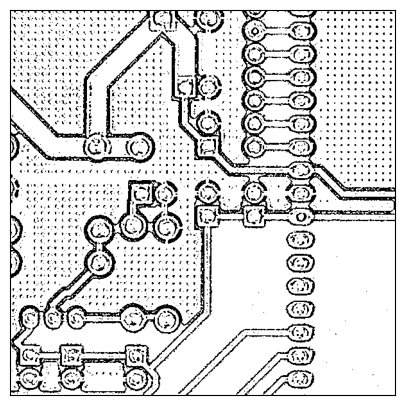

In [27]:
# task: applying adaptive threshold on gaussianblur filtered greyscale image

img_threshold_2 = cv2.adaptiveThreshold(filter_gb,255, 
                                        adaptiveMethod  = cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                        thresholdType = cv2.THRESH_BINARY,
                                        blockSize = 11,
                                        C = 5)


plt.figure(figsize = (8,5))

plt.imshow(img_threshold_2, cmap = 'gray')
plt.xticks([])
plt.yticks([])

plt.show();

([], [])

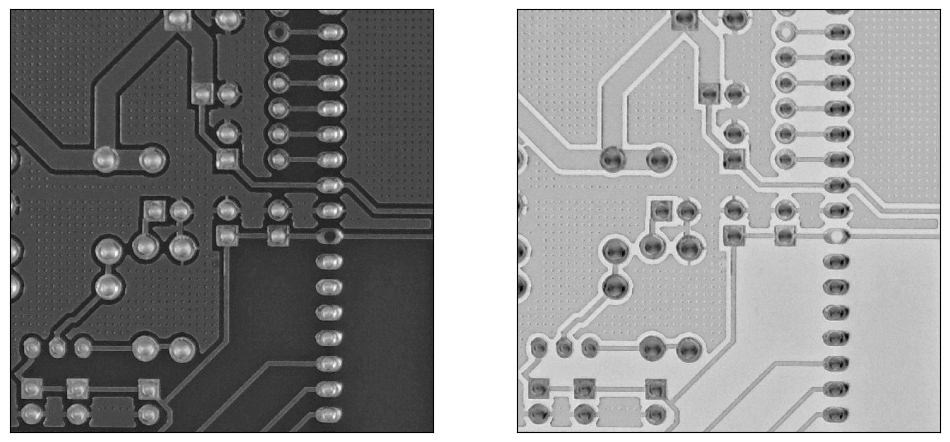

In [28]:
# task: subtracting image from white image to get spider grey tones and then applying gaussianblur filter

spider_gray = cv2.imread(user_image_path, cv2.IMREAD_GRAYSCALE)
# spider_gray = cv2.resize(spider_gray, (600,600))
spider_gray = 255 - spider_gray

filter_gb = cv2.GaussianBlur(spider_gray, ksize = (3,3), sigmaX = 0)
fig = plt.figure(figsize = (12,12))

fig.add_subplot(1,2,1)

plt.imshow(img_gray, cmap = 'gray')
plt.xticks([])
plt.yticks([])

fig.add_subplot(1,2,2)

plt.imshow(spider_gray, cmap = 'gray')
plt.xticks([])
plt.yticks([])
